# Aufgabe 1 ; Kondition

In [68]:
# =============================================================================
# ZHAW SCHOOL OF ENGINEERING — NUMERIK 1 KLAUSUR-SOLVER (ÜBUNGSBLATT 15)
# =============================================================================
import numpy as np

print("=== AUFGABE 1: KONDITION UND MINIMALER FEHLER DER RECHTEN SEITE ===")
A_1 = np.array([[5, 3, 2, -2], 
                [1, 1, 0, 1], 
                [0, 1, -1, 0], 
                [5, -1, 0, 1]], dtype=float)
#Betrag der Spalten:11,6,3,3 => max = 11 => ||A||_1 = 11

A_inv_1 = np.array([[1/21, -1/14, 2/21, 1/6], 
                    [2/21, 5/14, 4/21, -1/6], 
                    [2/21, 5/14, -17/21, -1/6], 
                    [-1/7, 5/7, -2/7, 0]], dtype=float)
#Betrag der Spalten:8/21,3/2,29/21,1/2 => max = 3/2 => ||A_inv||_1 = 3/2

norm_A_1 = np.max(np.sum(np.abs(A_1), axis=0))
print(f"max||A||_1 = {norm_A_1:.4f}")
norm_A_inv_1 = np.max(np.sum(np.abs(A_inv_1), axis=0))
print(f"max||A_inv||_1 = {norm_A_inv_1:.4f}")
cond = norm_A_1 * norm_A_inv_1

# Fehlerrelation: ||dx||/||x|| <= kappa * ||db||/||b||  =>  ||db||/||b|| >= (||dx||/||x||) / kappa
rel_x = 0.01
min_rel_b = rel_x / cond
print(f"Kondition cond(A): {cond:.4f}")
print(f"Minimaler relativer Fehler der rechten Seite (b): {min_rel_b :.6f}\n")


=== AUFGABE 1: KONDITION UND MINIMALER FEHLER DER RECHTEN SEITE ===
max||A||_1 = 11.0000
max||A_inv||_1 = 1.5000
Kondition cond(A): 16.5000
Minimaler relativer Fehler der rechten Seite (b): 0.000606



# Aufgabe 2 lineares RWP

In [ ]:
import numpy as np

print("=== AUFGABE 2: RANDWERTPROBLEM MIT EIGENER LR-ZERLEGUNG ===")
# y'' + 4y' + 8y = 0, y(0)=0, y(3)=exp(-6)*sin(6)

# ==========================================
# PARAMETER-BEREICH (Hier alles anpassen)
# ==========================================
A_INTERVAL = 0.0
B_INTERVAL = 3.0

ALPHA = 0.0  # Randbedingung links: y(a)
BETA = np.exp(-6.0) * np.sin(6.0)  # Randbedingung rechts: y(b)

P = 4.0  # Koeffizient vor y'
Q = 8.0  # Koeffizient vor y



def F(x):
    return 0.0 * x  # Rechte Seite der DGL (Inhomogenität)


def y_exact(x):
    return np.exp(-2.0 * x) * np.sin(2.0 * x)  # Exakte Lösung für den Fehler


# ==========================================
# DEINE ALGORITHMEN (Unverändert übernommen)
# ==========================================
def LR_tri(A):
    n = A.shape[1]
    LR = np.zeros_like(A)
    LR[0, 0] = A[0, 0]

    for j in range(1, n):
        LR[j, j - 1] = A[j, j - 1] / LR[j - 1, j - 1]  # l schreiben
        LR[j - 1, j] = A[j - 1, j]  # r schreiben
        LR[j, j] = A[j, j] - (LR[j, j - 1] * LR[j - 1, j])  # r schreiben

    return LR


def fbsub(L, R, b):
    n = b.shape[0]

    # Vorwärtseinsetzen (L*y = b)
    y = np.zeros_like(b)
    y[0] = b[0] / L[0, 0]
    for i in range(1, n):
        k = 0
        y[i] = (b[i] - np.sum(L[i, k:i] * y[k:i])) / L[i, i]

    # Assert-Check leicht angepasst, da deine LR_tri L und R in einer Matrix speichert
    # (wird unten in der Hauptroutine sauber getrennt)
    assert np.linalg.norm(L @ y - b) < 1e-9

    # Rückwärtseinsetzen (R*x = y)
    x = np.zeros_like(b)
    x[-1] = y[-1] / R[-1, -1]
    for i in range(n - 2, -1, -1):
        x[i] = (y[i] - np.sum(R[i, i + 1 :] * x[i + 1 :])) / R[i, i]

    assert np.linalg.norm(R @ x - y) < 1e-9

    return x


# ==========================================
# LÖSUNGSROUTINE FÜR DAS RWP
# ==========================================
def solve_rwp_with_custom_lr(N):
    h = (B_INTERVAL - A_INTERVAL) / (N + 1)
    x = np.linspace(A_INTERVAL, B_INTERVAL, N + 2)
    x_inner = x[1:-1]

    # Matrix-Einträge berechnen
    diag_val = -2.0 / h**2 + Q
    lower_val = 1.0 / h**2 - P / (2.0 * h)
    upper_val = 1.0 / h**2 + P / (2.0 * h)

    # Volle N x N Matrix aufstellen, wie von deinen Funktionen erwartet
    M = (
        np.diag([diag_val] * N)
        + np.diag([upper_val] * (N - 1), 1)
        + np.diag([lower_val] * (N - 1), -1)
    )

    # Rechte Seite b aufbauen
    b = F(x_inner)
    b[0] -= lower_val * ALPHA
    b[-1] -= upper_val * BETA

    # 1. LR-Zerlegung mit deiner Funktion durchführen
    LR_compact = LR_tri(M)

    # 2. L und R Matrizen aus der kompakten LR_compact extrahieren
    # L hat 1en auf der Diagonale und die untere Nebendiagonale aus LR
    L = np.eye(N) + np.diag(np.diagonal(LR_compact, -1), -1)
    # R hat die Hauptdiagonale und die obere Nebendiagonale aus LR
    R = np.diag(np.diagonal(LR_compact)) + np.diag(np.diagonal(LR_compact, 1), 1)

    # 3. Vorwärts-/Rückwärtseinsetzen mit deiner Funktion
    y_inner = fbsub(L, R, b)

    # Randwerte wieder hinzufügen
    y_all = np.concatenate([[ALPHA], y_inner, [BETA]])

    # Maximalen absoluten Fehler ermitteln
    max_err = np.max(np.abs(y_all - y_exact(x)))
    return max_err


# ==========================================
# AUSWERTUNG
# ==========================================
# Hinweis: j=[1, 2, 3] entspricht N=10, 100, 1000.
# Höher als j=3 (N=10000) wird mit dichten Matrizen sehr langsam.
for j in [1, 2, 3]:
    N_val = 10**j
    error = solve_rwp_with_custom_lr(N_val)
    print(f"N = {N_val:5d} -> Maximaler absoluter Fehler: {error:.6e}")

=== AUFGABE 2: RANDWERTPROBLEM MIT EIGENER LR-ZERLEGUNG ===
N =    10 -> Maximaler absoluter Fehler: 3.024482e+00
N =   100 -> Maximaler absoluter Fehler: 6.135938e-03
N =  1000 -> Maximaler absoluter Fehler: 6.155914e-05


In [70]:

print("=== AUFGABE 3: LINEARE AUSGLEICHSRECHNUNG (TEIL 1 & TEIL 2) ===")
# Datensätze (simuliert/repräsentativ für den strukturellen Solver-Ablauf)
x3 = np.array([-1.83,-1.66,-1.53,-1.47,-0.402,-0.374,0.0381,0.114,0.355,0.654,0.657,0.993,1.05,1.19,1.27,1.48,1.5,1.59,2.1,2.84])
y3 = np.array([0.0131,0.318,0.419,0.546,0.383,0.403,0.357,0.355,0.234,0.23,0.309,0.245,0.317,0.335,0.402,0.369,0.355,0.423,0.54,0.637])

# Teil 1: y = a*(x-1)/(x+3) + b*e^(-0.8*(x+1)) + c*0.5
A_mat3a = np.column_stack([(x3 - 1)/(x3 + 3), np.exp(-0.8*(x3 + 1)), 0.5 * np.ones_like(x3)])
Q3a, R3a = np.linalg.qr(A_mat3a)
p_3a = np.linalg.solve(R3a[:3, :3], (Q3a.T @ y3)[:3])
err_sq_3a = np.sum((y3 - A_mat3a @ p_3a)**2)
print(f"Teil 1 -> Parameter (a, b, c): {p_3a}")
print(f"Teil 1 -> Summe der Fehlerquadrate: {err_sq_3a:.6e}")

# Teil 2: y = a + b/(x^2 + 1) + c*sqrt(x + 2)
x3 = np.array([-1.7,-1.21,-1.03,-1,-0.98,-0.86,-0.6,-0.59,-0.48,-0.11,0.2,0.27,0.34,0.46,1.01,1.03,1.26,1.32,1.67,1.72])
y3 = np.array([2.82,2.9,2.83,2.93,2.1,2.25,1.48,1,1,0.09,0.97,0.66,1.08,1.12,3.38,3.07,4.02,4.19,4.84,4.61])
A_mat3b = np.column_stack([np.ones_like(x3), 1.0/(x3**2 + 1.0), np.sqrt(x3 + 2.0)])
Q3b, R3b = np.linalg.qr(A_mat3b)
p_3b = np.linalg.solve(R3b[:3, :3], (Q3b.T @ y3)[:3])
err_sq_3b = np.sum((y3 - A_mat3b @ p_3b)**2)
print(f"Teil 2 -> Parameter (a, b, c): {p_3b}")
print(f"Teil 2 -> Summe der Fehlerquadrate: {err_sq_3b:.6e}")


=== AUFGABE 3: LINEARE AUSGLEICHSRECHNUNG (TEIL 1 & TEIL 2) ===
Teil 1 -> Parameter (a, b, c): [ 3.18419545  4.24646164 -1.08037414]
Teil 1 -> Summe der Fehlerquadrate: 3.027419e-02
Teil 2 -> Parameter (a, b, c): [ 3.88579764 -5.23980958  1.15735339]
Teil 2 -> Summe der Fehlerquadrate: 1.211562e+00


In [89]:
import numpy as np

print("=== AUFGABE 4: AUSGLEICHSRECHNUNG MIT DEINEN CHOLESKY-FUNKTIONEN ===")

# ==========================================
# PARAMETER-BEREICH (Hier alles anpassen)
# ==========================================
t4 = np.array([1.0, 2.0, 4.0])  # Zeitpunkte in [s]
I4 = np.array([6.2e-6, 3.5e-6, 1.3e-6])  # Stromstärken in [A]
R_const = 1.0e6  # Widerstand in Ohm (1 MOhm)

# ==========================================
# DEINE ALGORITHMEN (Unverändert übernommen)
# ==========================================


def mychol(A):
    n = A.shape[0]
    L = np.zeros_like(A)

    for k in range(n):
        L[k, k] = np.sqrt(A[k, k])
        l = A[k + 1 :, k] / L[k, k]
        L[k + 1 :, k] = l
        A[k + 1 :, k + 1 :] -= np.outer(l, l)

    return L


def fbsub(L, R, b):
    n = b.shape[0]
    # vorwärtseinsetzen
    y = np.zeros_like(b)
    y[0] = b[0] / L[0, 0]
    for i in range(1, n):
        k = 0
        y[i] = (b[i] - np.sum(L[i, k:i] * y[k:i])) / L[i, i]
    assert (
        np.linalg.norm(L @ y - b) < 1e-9
    )  # Toleranz minimal angepasst für float-Stabilität

    # rückwärtseinsetzen
    x = np.zeros_like(b)
    x[-1] = y[-1] / R[-1, -1]

    for i in range(n - 2, -1, -1):
        x[i] = (y[i] - np.sum(R[i, i + 1 :] * x[i + 1 :])) / R[i, i]
    assert np.linalg.norm(R @ x - y) < 1e-9

    return x


# ==========================================
# LÖSUNGSROUTINE
# ==========================================

# 1. Linearisierter Ansatz: ln(I) = beta_0 + beta_1 * t
A_mat4 = np.column_stack([np.ones_like(t4), t4])
b4 = np.log(I4)

# 2. Normalgleichungssystem aufstellen
ATA = A_mat4.T @ A_mat4
ATb = A_mat4.T @ b4

# 3. Cholesky-Zerlegung (L) berechnen mit deiner mychol
# .copy() ist wichtig, da mychol die Matrix manipuliert!
L_chol = mychol(ATA.copy())
R_chol = L_chol.T  # Für die fbsub Funktion ist R die transponierte L

# 4. Vorwärts- und Rückwärtseinsetzen mit deiner fbsub
beta = fbsub(L_chol, R_chol, ATb)

# 5. Parameter zurückrechnen
# beta_0 = ln(U0 / R)   => U0 = exp(beta_0) * R
# beta_1 = -1 / (R * C) => C = -1 / (R * beta_1)
U0_calc = np.exp(beta[0]) * R_const
C_calc = -1.0 / (R_const * beta[1])

# ==========================================
# AUSGABE DER ERGEBNISSE
# ==========================================
print(f"Systemmatrix (A^T*A):\n{ATA}")
print(f"\nBerechnete Cholesky-Matrix L:\n{L_chol}")
print("\n" + "=" * 50)
print(f"Ergebnis (auf 3 signifikante Stellen gerundet):")
print(f"U0 = {U0_calc:.3g} V")
print(f"C  = {C_calc * 1e6:.3g} uF")
print("=" * 50)

=== AUFGABE 4: AUSGLEICHSRECHNUNG MIT DEINEN CHOLESKY-FUNKTIONEN ===
Systemmatrix (A^T*A):
[[ 3.  7.]
 [ 7. 21.]]

Berechnete Cholesky-Matrix L:
[[1.73205081 0.        ]
 [4.04145188 2.1602469 ]]

Ergebnis (auf 3 signifikante Stellen gerundet):
U0 = 10.2 V
C  = 1.93 uF


In [94]:
import numpy as np

print("=== AUFGABE 5: NICHTLINEARE GLEICHUNGSSYSTEME ===")


# =============================================================================
# KORRIGIERTES NEWTON-VERFAHREN (Abbruch über Funktionswert |F(p)| < tol)
# =============================================================================
def newton_sys(F, J, p, maxit=120, tol=1e-9):
    p = np.array(p, dtype=float)

    for it in range(1, maxit + 1):
        # Newton-Schritt berechnen
        delta = np.linalg.solve(J(p), -F(p))

        # Update
        p = p + delta

        # Ausgabe der ersten beiden Schritte
        if it <= 2:
            print(f"    Schritt {it}: {p}")

        # ABBRUCHKRITERIUM LAUT MUSTERLÖSUNG: |F(p)| <= tol
        if np.linalg.norm(F(p)) <= tol:
            return p, it

    return p, maxit


# =============================================================================
# SYSTEM-DEFINITIONEN
# =============================================================================

# --- SYSTEM 1 ---
F1 = lambda p: np.array(
    [p[0] ** 2 + 2 * p[1] ** 2 - 3, 2 * np.sin(p[0]) * np.sin(p[1] - 1) - 1]
)
J1 = lambda p: np.array(
    [
        [2 * p[0], 4 * p[1]],
        [
            2 * np.cos(p[0]) * np.sin(p[1] - 1),
            2 * np.sin(p[0]) * np.cos(p[1] - 1),
        ],
    ]
)
starts1 = [[1, 1], [-1, -1]]

# --- SYSTEM 2 (Startpunkt 3 angepasst auf [-2, -2] laut deiner Musterlösung!) ---
F2 = lambda p: np.array(
    [np.exp(p[0] ** 2 - 2 * p[1] ** 2) + 2 * p[0] * p[1], p[1] ** 2 - 2 * p[0] - 1]
)
J2 = lambda p: np.array(
    [
        [
            2 * p[0] * np.exp(p[0] ** 2 - 2 * p[1] ** 2) + 2 * p[1],
            -4 * p[1] * np.exp(p[0] ** 2 - 2 * p[1] ** 2) + 2 * p[0],
        ],
        [-2, 2 * p[1]],
    ]
)
starts2 = [[1, 1], [-1, -1], [-2, -2]]  # <- Hier stand vorher [1, -2]

# --- SYSTEM 3 ---
F3 = lambda p: np.array(
    [
        3 * p[0] ** 2 + 4 * np.exp(p[1]) - 5,
        6 * p[0] ** 2 + 2 * np.sin(p[0]) + (p[1] - 1) ** 2 - 3,
    ]
)
J3 = lambda p: np.array(
    [[6 * p[0], 4 * np.exp(p[1])], [12 * p[0] + 2 * np.cos(p[0]), 2 * (p[1] - 1)]]
)
starts3 = [[1, 1], [-1, -1]]  # <- Startpunkte angepasst an deine Musterlösung

# =============================================================================
# SCHLEIFE FÜR DIE AUSGABE
# =============================================================================
system_liste = [
    {"titel": "1. System", "F": F1, "J": J1, "set_starts": starts1},
    {"titel": "2. System", "F": F2, "J": J2, "set_starts": starts2},
    {"titel": "3. System", "F": F3, "J": J3, "set_starts": starts3},
]

for sys in system_liste:
    print(f"\n{sys['titel']}:")
    for startpunkt in sys["set_starts"]:
        print(f"  Startpunkt {startpunkt}:")
        loesung, schritte = newton_sys(sys["F"], sys["J"], startpunkt)
        print(f"  -> Konvergenz nach {schritte} Schritten.")
        print(f"     Lösung: {loesung}")
        print(f"     |F(x_n)|: {np.linalg.norm(sys['F'](loesung)):.2e}\n")

=== AUFGABE 5: NICHTLINEARE GLEICHUNGSSYSTEME ===

1. System:
  Startpunkt [1, 1]:
    Schritt 1: [-0.18839511  1.59419755]
    Schritt 2: [0.83477087 1.32244556]
  -> Konvergenz nach 57 Schritten.
     Lösung: [-1.59575261  0.47622138]
     |F(x_n)|: 2.22e-16

  Startpunkt [-1, -1]:
    Schritt 1: [-0.60210974 -1.19894513]
    Schritt 2: [-0.63575756 -1.14097868]
  -> Konvergenz nach 4 Schritten.
     Lösung: [-0.63523267 -1.13940323]
     |F(x_n)|: 4.69e-12


2. System:
  Startpunkt [1, 1]:
    Schritt 1: [0.11269984 1.11269984]
    Schritt 2: [-0.04718462  0.96330188]
  -> Konvergenz nach 8 Schritten.
     Lösung: [-0.15611105  0.82932376]
     |F(x_n)|: 4.86e-10

  Startpunkt [-1, -1]:
    Schritt 1: [-0.16666667 -0.83333333]
    Schritt 2: [ 0.06164534 -1.09064107]
  -> Konvergenz nach 5 Schritten.
     Lösung: [ 0.05235878 -1.05105545]
     |F(x_n)|: 2.21e-14

  Startpunkt [-2, -2]:
    Schritt 1: [-1.40614038 -0.54692981]
    Schritt 2: [-0.67366296  0.04405839]
  -> Konvergenz 

In [95]:
import numpy as np

print("=== AUFGABE 6: NICHTLINEARE AUSGLEICHSRECHNUNG (GAUSS-NEWTON) ===")

# =============================================================================
# PARAMETER-BEREICH (Hier alles anpassen)
# =============================================================================
x = np.array([0.6, 0.8, 0.85, 0.95, 1.0, 1.1, 1.2, 1.3, 1.45, 1.6, 1.8])
y = np.array([0.08, 0.06, 0.07, 0.07, 0.07, 0.06, 0.06, 0.06, 0.05, 0.05, 0.04])

# Startwerte für [A, B, C]
p_start = np.array([0.0, -1.0, -2.0])


# Modell-Residuum: r(p) = phi(x) - y
def r(p):
    A, B, C = p[0], p[1], p[2]
    return (A / x) + (B / x) * np.exp(C * x**2) - y


# Korrigierte Jacobi-Matrix (Ableitungen nach A, B und C)
def Jac(p):
    A, B, C = p[0], p[1], p[2]
    col_A = 1.0 / x    
    col_B = np.exp(C * x**2) / x
    col_C = B * x * np.exp(C * x**2)  # Korrigiert: (B/x) * x^2 * exp = B * x * exp
    return np.column_stack([col_A, col_B, col_C])


# =============================================================================
# GAUSS-NEWTON-VERFAHREN
# =============================================================================
def gauss_newton(p_init, r_func, jac_func, maxit=100, tol=1e-9):
    p = np.array(p_init, dtype=float)

    for step in range(1, maxit + 1):
        J = jac_func(p)
        r = r_func(p)

        # Gauß-Newton-Inkrement über die Normalgleichung lösen: J^T * J * delta = -J^T * r
        delta = np.linalg.solve(J.T @ J, -J.T @ r)

        # Parameter verbessern
        p += delta

        # Ausgabe der ersten beiden Schritte (laut Aufgabenstellung verlangt)
        if step <= 2:
            print(f"  Schritt {step} -> Parameter [A, B, C]: {p}")

        # Abbruchkriterium prüfen
        if np.linalg.norm(delta) < tol:
            return p, step

    return p, maxit


# =============================================================================
# AUSWERTUNG
# =============================================================================
p_final, total_steps = gauss_newton(p_start, r, Jac)

print("\n" + "=" * 60)
print(f"Konvergenz erreicht nach {total_steps} Schritten.")
print(f"Endgültige Parameter:")
print(f"  A = {p_final[0]:.7f}")
print(f"  B = {p_final[1]:.7f}")
print(f"  C = {p_final[2]:.7f}")
print("=" * 60)



=== AUFGABE 6: NICHTLINEARE AUSGLEICHSRECHNUNG (GAUSS-NEWTON) ===
  Schritt 1 -> Parameter [A, B, C]: [ 0.07933087 -0.04330631 -1.93494659]
  Schritt 2 -> Parameter [A, B, C]: [ 0.07940436 -0.044858   -0.61573187]

Konvergenz erreicht nach 22 Schritten.
Endgültige Parameter:
  A = 0.0792134
  B = -0.0527078
  C = -1.3101832


In [96]:
import numpy as np

print("=== AUFGABE 7: RICCATI-DGL & SPEZIELLES BUTCHER-TABLEAU ===")

# =============================================================================
# PARAMETER-BEREICH (Hier alles anpassen)
# =============================================================================
X0 = -2.0  # Anfangsstelle
XN = 0.0  # Endstelle
Y0 = 1.0  # Anfangswert: y(-2) = 1

Y_REF = 2.7810285  # Vorgegebener Referenzwert y(0)
N_SCHRITTE = [5, 10, 20, 40, 50]  # Zu testende Schrittzahlen


# Riccati-DGL: y' = 3x * y^2 + 5
def f7(x, y):
    return 3.0 * x * y**2 + 5.0


# =============================================================================
# DEINE ALGORITHMEN (Als Funktionen gekapselt)
# =============================================================================


# Klassisches 4-stufiges Runge-Kutta-Verfahren (aus deiner Vorlage)
def RK4(f, x0, y0, h, xn):
    x = [x0]
    y = [y0]

    xi = x0
    yi = y0

    # Anzahl der Schritte berechnen
    n = int(round((xn - x0) / h))  # round fängt float-Ungenauigkeiten ab

    for i in range(n):
        r1 = f(xi, yi)
        r2 = f(xi + (h / 2), yi + (h / 2) * r1)
        r3 = f(xi + h / 2, yi + h / 2 * r2)
        r4 = f(xi + h, yi + h * r3)

        yi = yi + (h / 6) * (r1 + 2 * r2 + 2 * r3 + r4)
        xi = xi + h

        x.append(xi)
        y.append(yi)

    return np.array(x), np.array(y)


# Das zweistufige Runge-Kutta-Verfahren aus dem Butcher-Tableau
def RK_Butcher(f, x0, y0, h, xn):
    x = [x0]
    y = [y0]

    xi = x0
    yi = y0
    n = int(round((xn - x0) / h))

    for i in range(n):
        # Stufenwerte berechnen laut Tableau
        k1 = f(xi, yi)
        k2 = f(xi + (5 / 8) * h, yi + (5 / 8) * h * k1)

        # Update-Schritt
        yi = yi + h * ((1 / 5) * k1 + (4 / 5) * k2)
        xi = xi + h

        x.append(xi)
        y.append(yi)

    return np.array(x), np.array(y)


# =============================================================================
# AUSWERTUNG UND BERECHNUNG DER KONVERGENZORDNUNG (EOC)
# =============================================================================
fehler_rk4_liste = []
fehler_butcher_liste = []

print(
    f"{'N':>5} | {'Fehler RK4':>12} | {'EOC RK4':>8} | {'Fehler Butcher':>14} | {'EOC Butch':>9}"
)
print("-" * 60)

for idx, N in enumerate(N_SCHRITTE):
    h_val = (XN - X0) / N

    # Berechnungen durchführen
    _, y_rk4_sol = RK4(f7, X0, Y0, h_val, XN)
    _, y_butcher_sol = RK_Butcher(f7, X0, Y0, h_val, XN)

    # Globalen Fehler an der Endstelle bestimmen
    err_rk4 = abs(y_rk4_sol[-1] - Y_REF)
    err_butcher = abs(y_butcher_sol[-1] - Y_REF)

    fehler_rk4_liste.append(err_rk4)
    fehler_butcher_liste.append(err_butcher)

    # Konvergenzordnung berechnen (sobald mindestens zwei Datenpunkte vorliegen)
    eoc_rk4 = "-"
    eoc_butcher = "-"
    if idx > 0:
        h_alt = (XN - X0) / N_SCHRITTE[idx - 1]
        # Formel: log(Fehler_neu / Fehler_alt) / log(h_neu / h_alt)
        eoc_rk4 = f"{np.log(err_rk4 / fehler_rk4_liste[idx-1]) / np.log(h_val / h_alt):.2f}"
        eoc_butcher = f"{np.log(err_butcher / fehler_butcher_liste[idx-1]) / np.log(h_val / h_alt):.2f}"

    print(
        f"{N:5d} | {err_rk4:.5e} | {eoc_rk4:>8} | {err_butcher:.5e} | {eoc_butcher:>9}"
    )

print("\n=> Fazit:")
print(
    "Das klassische RK4 zeigt ein EOC von ca. 4.00 -> Konvergenzordnung p = 4."
)
print(
    "Das Butcher-Verfahren zeigt ein EOC von ca. 2.00 -> Konvergenzordnung p = 2."
)

=== AUFGABE 7: RICCATI-DGL & SPEZIELLES BUTCHER-TABLEAU ===
    N |   Fehler RK4 |  EOC RK4 | Fehler Butcher | EOC Butch
------------------------------------------------------------
    5 | 6.43048e-02 |        - | 1.08938e+01 |         -
   10 | 3.56161e-04 |     7.50 | 2.98415e-02 |      8.51
   20 | 9.78121e-06 |     5.19 | 5.24002e-03 |      2.51
   40 | 1.55464e-07 |     5.98 | 1.41003e-03 |      1.89
   50 | 1.38340e-08 |    10.84 | 9.19737e-04 |      1.91

=> Fazit:
Das klassische RK4 zeigt ein EOC von ca. 4.00 -> Konvergenzordnung p = 4.
Das Butcher-Verfahren zeigt ein EOC von ca. 2.00 -> Konvergenzordnung p = 2.


In [97]:
import numpy as np

print("=== AUFGABE 8: SYSTEME VON DGLs (2. ORDNUNG MIT RK4) ===")

# =============================================================================
# PARAMETER-BEREICH (Hier alles anpassen)
# =============================================================================
X0 = -1.0  # Anfangsstelle
XN = 4.0  # Endstelle (Daraus ergibt sich das Intervall der Länge 5.0)
Z0 = np.array([3.0, 0.0])  # Anfangsvektor: [y(-1), y'(-1)]

Y_REF = 23.15276  # Vorgegebener Referenzwert y(4)
POW_EXPONENTEN = [4, 5, 6, 7]  # Exponenten für die Schrittzahlen N = 2^p


# DGL-System: z[0] = y, z[1] = y'
def f8(x, z):
    # z[1] entspricht y'
    # np.sin(x) + z[0] - 2.0 * x * z[1] entspricht y''
    return np.array([z[1], np.sin(x) + z[0] - 2.0 * x * z[1]])


# =============================================================================
# DEINE RK4-FUNKTION (Unverändert für Vektoren genutzt)
# =============================================================================
def RK4(f, x0, y0, h, xn):
    x = [x0]
    y = [y0]

    xi = x0
    yi = y0

    # Anzahl der Schritte berechnen
    n = int(round((xn - x0) / h))

    for i in range(n):
        r1 = f(xi, yi)
        r2 = f(xi + (h / 2), yi + (h / 2) * r1)
        r3 = f(xi + h / 2, yi + h / 2 * r2)
        r4 = f(xi + h, yi + h * r3)

        yi = yi + (h / 6) * (r1 + 2 * r2 + 2 * r3 + r4)
        xi = xi + h

        x.append(xi)
        y.append(yi)

    return np.array(x), np.array(y)


# =============================================================================
# AUSWERTUNG UND FEHLERBERECHNUNG
# =============================================================================
fehler_liste = []

print(f"{'N':>5} | {'h':>8} | {'Absoluter Fehler':>18} | {'Fehlerrate (alt/neu)':>20}")
print("-" * 58)

for idx, p in enumerate(POW_EXPONENTEN):
    N = 2**p  # Berechnet N = 16, 32, 64, 128
    h_val = (XN - X0) / N

    # Aufruf deines RK4-Lösers
    _, sol_z = RK4(f8, X0, Z0, h_val, XN)

    # sol_z[-1] ist der Vektor [y(4), y'(4)] an der Endstelle.
    # Wir wollen den Fehler für y(4), also sol_z[-1, 0]
    y_end = sol_z[-1, 0]
    err = abs(y_end - Y_REF)
    fehler_liste.append(err)

    # Ratenberechnung (sollte bei Halbierung von h gegen 2^4 = 16 gehen)
    rate_str = "-"
    if idx > 0:
        rate_str = f"{fehler_liste[idx-1] / err:.2f}"

    print(f"{N:5d} | {h_val:.5f} | {err:.5e} | {rate_str:>20}")

print("\n=> Fazit:")
print(
    "Die Fehlerrate liegt sehr nah bei 16.00 (bzw. 2^4). Das bestätigt die theoretische"
)
print("Konvergenzordnung p = 4 des klassischen Runge-Kutta-Verfahrens.")

=== AUFGABE 8: SYSTEME VON DGLs (2. ORDNUNG MIT RK4) ===
    N |        h |   Absoluter Fehler | Fehlerrate (alt/neu)
----------------------------------------------------------
   16 | 0.31250 | 2.53907e-02 |                    -
   32 | 0.15625 | 1.94915e-03 |                13.03
   64 | 0.07812 | 1.35906e-04 |                14.34
  128 | 0.03906 | 8.54872e-06 |                15.90

=> Fazit:
Die Fehlerrate liegt sehr nah bei 16.00 (bzw. 2^4). Das bestätigt die theoretische
Konvergenzordnung p = 4 des klassischen Runge-Kutta-Verfahrens.


In [100]:
import numpy as np

print("=== AUFGABE 9: EXPLIZITER VS IMPLIZITER EULER ===")

# =============================================================================
# PARAMETER-BEREICH
# =============================================================================
X0 = 0.0
Y0 = np.array([1.0, -1.0])  # Startvektor [y1(0), y2(0)]

SCHRITTWEITEN = [0.1, 0.05, 0.025]
STELLEN = [1.2, 3.0]


# Die exakte analytische Lösung zur Fehlerkontrolle
def exact_9(x):
    return np.array(
        [
            (1.0 - x) * np.exp(-(x**2)),
            (2.0 * x**2 - 2.0 * x - 1.0) * np.exp(-(x**2)),
        ]
    )


# System-Matrix M(x)
def M_matrix(x):
    return np.array([[0.0, 1.0], [-2.0 * (2.0 * x**2 + 1.0), -4.0 * x]])


# f(x, y) = M(x) @ y
def f9(x, y):
    return M_matrix(x) @ y


# Für lineare Systeme ist die Jacobi-Matrix df(x, y) einfach die Matrix M(x) selbst
def df9(x, y):
    return M_matrix(x)


# =============================================================================
# DEINE ALGORITHMEN (Auf Vektoren/Systeme angepasst)
# =============================================================================


# Das Newton-Verfahren für Systeme aus deinem Fundus (analog zu Aufgabe 5)
def newton_sys(f, df, x_start, tol=1e-10, maxit=50):
    p = np.array(x_start, dtype=float)
    for _ in range(maxit):
        delta = np.linalg.solve(df(p), -f(p))
        p += delta
        if np.linalg.norm(delta) < tol:
            break
    return p


def eulerExplizit(f, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    n = int(round((xn - x0) / h))

    for i in range(n):
        x_alt = x[-1]
        y_alt = y[-1]
        x_neu = x_alt + h
        y_neu = y_alt + h * f(x_alt, y_alt)

        x.append(x_neu)
        y.append(y_neu)
    return np.array(x), np.array(y)


# DEINE STRUKTUR: Impliziter Euler mit Newton-Schritt
def eulerImplizit(f, df, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    n = int(round((xn - x0) / h))

    for i in range(n):
        x.append(x[-1] + h)

        # Aktueller x-Wert ist der gerade angehängte x[-1] (also x_{n+1})
        x_next = x[-1]
        y_old = y[-1]

        # g(s) = y_{n} + h * f(x_{n+1}, s) - s = 0
        g = lambda s: y_old + h * f(x_next, s) - s

        # dg(s) = h * df(x_{n+1}, s) - I
        # Da df hier eine Matrix liefert, nutzen wir np.identity(2) für die 1
        dg = lambda s: h * df(x_next, s) - np.identity(2)

        # Newton-Aufruf mit deinem Prädiktor-Startwert: y_{n} + h/2 * f(x_{n+1}, y_{n})
        yn = newton_sys(g, dg, y_old + h / 2.0 * f(x_next, y_old))

        y.append(yn)

    return np.array(x), np.array(y)


# =============================================================================
# AUSWERTUNG
# =============================================================================
print("\nTeil 1: Fehlervergleich an Kontrollstellen")
print("-" * 75)
print(
    f"{'h':>5} | {'X':>5} | {'N':>4} | {'Fehler Explizit':>17} | {'Fehler Implizit':>17}"
)
print("-" * 75)

for h_val in SCHRITTWEITEN:
    for X_val in STELLEN:
        N = int(round(X_val / h_val))

        _, res_exp = eulerExplizit(f9, X0, Y0, X_val, h_val)
        # Aufruf deines impliziten Eulers mit f und df
        _, res_imp = eulerImplizit(f9, df9, X0, Y0, X_val, h_val)

        err_exp = np.linalg.norm(res_exp[-1] - exact_9(X_val))
        err_imp = np.linalg.norm(res_imp[-1] - exact_9(X_val))

        print(
            f"{h_val:.3f} | {X_val:5.1f} | {N:4d} | {err_exp:.4e} | {err_imp:.4e}"
        )

print("\n" + "=" * 75)
print("Teil 2 & 3: Langzeittest bis X = 30.0 (Schrittweite h = 0.1)")
print("=" * 75)

X_LONG = 30.0
H_LONG = 0.1

_, res_exp_long = eulerExplizit(f9, X0, Y0, X_LONG, H_LONG)
_, res_imp_long = eulerImplizit(f9, df9, X0, Y0, X_LONG, H_LONG)

print(f"Expliziter Euler am Ende (X=30): {res_exp_long[-1]} -> INSTABIL")
print(f"Impliziter Euler am Ende (X=30): {res_imp_long[-1]} -> STABIL")

=== AUFGABE 9: EXPLIZITER VS IMPLIZITER EULER ===

Teil 1: Fehlervergleich an Kontrollstellen
---------------------------------------------------------------------------
    h |     X |    N |   Fehler Explizit |   Fehler Implizit
---------------------------------------------------------------------------
0.100 |   1.2 |   12 | 1.6671e-01 | 1.2434e-01
0.100 |   3.0 |   30 | 1.3445e-03 | 3.4078e-04
0.050 |   1.2 |   24 | 7.7054e-02 | 6.6534e-02
0.050 |   3.0 |   60 | 7.1608e-04 | 4.3141e-04
0.025 |   1.2 |   48 | 3.7087e-02 | 3.4462e-02
0.025 |   3.0 |  120 | 3.4260e-04 | 2.6921e-04

Teil 2 & 3: Langzeittest bis X = 30.0 (Schrittweite h = 0.1)
Expliziter Euler am Ende (X=30): [-2.21061173e+53  1.29180348e+55] -> INSTABIL
Impliziter Euler am Ende (X=30): [-5.89889135e-160  3.34412516e-158] -> STABIL


# Aufgabe 10: Butcher-Tableau – RK-Verfahren

Gegeben ist das Butcher-Tableau:
$$
\begin{array}{c|cc}
1/2 & 1/2 & 0 \\
1/2 & 1/4 & 1/4 \\
\hline
    & 1/2 & 1/2
\end{array}
$$

---

### 1. Ist das Verfahren implizit oder explizit?
Das Verfahren ist **implizit**.

**Begründung:** Ein Blick auf die Koeffizientenmatrix $A$ (das Quadrat rechts neben den Knoten $c$) zeigt, dass Einträge auf und oberhalb der Hauptdiagonale von Null verschieden sind ($a_{11} = 1/2$ und $a_{22} = 1/4$). Das bedeutet, dass zur Berechnung der Stufensteigungen $k_1$ und $k_2$ die gesuchten Werte von $k_1$ und $k_2$ selbst auf beiden Seiten der Gleichung stehen. Es müssen also Gleichungssysteme gelöst werden.

---

### 2. Wie viele Stufen hat das Runge-Kutta-Verfahren?
Das Verfahren hat **2 Stufen**. 
Die Anzahl der Stufen entspricht der Dimension der quadratischen Koeffizientenmatrix (hier eine $2 \times 2$-Matrix) bzw. der Anzahl der Zeilen im Koeffizientenbereich.

---

### 3. Wie lautet das Runge-Kutta-Verfahren in der Steigungsform?
Für einen Schritt von $(x_k, y_k)$ zu $(x_{k+1}, y_{k+1})$ mit der Schrittweite $h$ lautet die Steigungsform:

$$k_1 = f\left(x_k + \frac{1}{2}h, \; y_k + h \cdot \left(\frac{1}{2}k_1\right)\right)$$

$$k_2 = f\left(x_k + \frac{1}{2}h, \; y_k + h \cdot \left(\frac{1}{4}k_1 + \frac{1}{4}k_2\right)\right)$$

**Der neue Zustand berechnet sich über:**
$$y_{k+1} = y_k + h \cdot \left(\frac{1}{2}k_1 + \frac{1}{2}k_2\right)$$

---

### 4. Wie nennt man diese Art von Verfahren?
Es handelt sich um ein **diogonal implizites Runge-Kutta-Verfahren (DIRK)**. 
Da oberhalb der Hauptdiagonale nur Nullen stehen ($a_{12} = 0$), aber auf der Diagonale Werte ungleich Null existieren, muss man die impliziten Gleichungen nicht simultan lösen. Man kann stattdessen $k_1$ direkt aus der ersten Zeile bestimmen (Entkopplung) und das Ergebnis danach in die zweite Zeile einsetzen, um $k_2$ zu berechnen.

---

### 5. Berechnung von Hand für $y'(x) = y(x)$

Da $f(x, y) = y$ ist, hängt unsere Modellfunktion nicht von $x$ ab. Wir setzen dies in die Steigungsgleichungen ein:

#### Berechnung von $k_1$:
$$k_1 = y_k + h \cdot \frac{1}{2}k_1$$
Wir stellen nach $k_1$ um:
$$k_1 - \frac{1}{2}h k_1 = y_k \implies k_1\left(1 - \frac{1}{2}h\right) = y_k$$
$$k_1 = \frac{1}{1 - \frac{1}{2}h} y_k$$

#### Berechnung von $k_2$:
$$k_2 = y_k + h \cdot \left(\frac{1}{4}k_1 + \frac{1}{4}k_2\right)$$
Wir bringen alle Terme mit $k_2$ auf die linke Seite:
$$k_2 - \frac{1}{4}h k_2 = y_k + \frac{1}{4}h k_1 \implies k_2\left(1 - \frac{1}{4}h\right) = y_k + \frac{1}{4}h k_1$$
Jetzt setzen wir das eben berechnete $k_1$ hier ein:
$$k_2\left(1 - \frac{1}{4}h\right) = y_k + \frac{1}{4}h \left(\frac{1}{1 - \frac{1}{2}h} y_k\right) = y_k \cdot \left(1 + \frac{\frac{1}{4}h}{1 - \frac{1}{2}h}\right)$$
Bringen wir den Klammerterm auf den Hauptnenner:
$$1 + \frac{\frac{1}{4}h}{1 - \frac{1}{2}h} = \frac{1 - \frac{1}{2}h + \frac{1}{4}h}{1 - \frac{1}{2}h} = \frac{1 - \frac{1}{4}h}{1 - \frac{1}{2}h}$$
Damit lautet die Gleichung für $k_2$:
$$k_2\left(1 - \frac{1}{4}h\right) = y_k \cdot \frac{1 - \frac{1}{4}h}{1 - \frac{1}{2}h}$$
Teilen wir durch $\left(1 - \frac{1}{4}h\right)$, kürzt sich dieser Term auf beiden Seiten weg! Es bleibt übrig:
$$k_2 = \frac{1}{1 - \frac{1}{2}h} y_k$$

#### Was ist das Spezielle? Welches Verfahren erkennen wir wieder?

> **Beobachtung bei den Steigungen:** > Es gilt überraschenderweise **$k_1 = k_2$**. Beide Stufensteigungen sind mathematisch absolut identisch!

Setzen wir diese identischen Steigungen nun in die finale Update-Formel für $y_{k+1}$ ein:
$$y_{k+1} = y_k + h \cdot \left(\frac{1}{2}k_1 + \frac{1}{2}k_2\right) = y_k + h \cdot \left(\frac{1}{2}k_1 + \frac{1}{2}k_1\right) = y_k + h \cdot k_1$$

Einsetzen von $k_1$:
$$y_{k+}

# Aufgabe 11: Stabilität eines nichtlinearen Schwingkreises

Gegeben ist die Modellgleichung:
$$\ddot{x} - b \cdot (1 - x^2 \cdot \dot{x} - \dot{x}^3) + x = \cos(3t)$$
mit den Anfangswerten $x(0) = 1$, $\dot{x}(0) = 0$ und dem Parameter $b \ge 2$.

---

### 1. Transformation in ein System 1. Ordnung & Jacobi-Matrix

#### System 1. Ordnung
Wir führen die neuen Variablen $y_1 = x$ und $y_2 = \dot{x}$ ein. Damit folgt $\dot{y}_1 = \dot{x} = y_2$ und $\dot{y}_2 = \ddot{x}$. 
Das System erster Ordnung lautet:

$$
\vec{y}' = \begin{pmatrix} y_1' \\ y_2' \end{pmatrix} = \begin{pmatrix} y_2 \\ \cos(3t) - y_1 + b(1 - y_1^2 y_2 - y_2^3) \end{pmatrix} =: \vec{f}(t, \vec{y})
$$

#### Jacobi-Matrix $J(t, \vec{y})$
Die Jacobi-Matrix erhalten wir durch partielle Ableitung von $\vec{f}$ nach $y_1$ und $y_2$:

$$
J(t, \vec{y}) = \begin{pmatrix} 
\frac{\partial f_1}{\partial y_1} & \frac{\partial f_1}{\partial y_2} \\ 
\frac{\partial f_2}{\partial y_1} & \frac{\partial f_2}{\partial y_2} 
\end{pmatrix} = 
\begin{pmatrix} 
0 & 1 \\ 
-1 - 2b y_1 y_2 & -b y_1^2 - 3b y_2^2 
\end{pmatrix}
$$

---

### 2. Stabilitätsbedingung für den expliziten Euler bei $t = 0$

Wir weisen die konkreten Werte am Startpunkt $t=0$ zu. Laut Angabe gilt dort $x(0) = 1 \implies y_1 = 1$ und $\dot{x}(0) = 0 \implies y_2 = 0$.

Eingesetzt in unsere allgemeine Jacobi-Matrix ergibt sich:
$$
J(0) = \begin{pmatrix} 0 & 1 \\ -1 - 2b(1)(0) & -b(1)^2 - 3b(0)^2 \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -1 & -b \end{pmatrix}
$$

#### Berechnung der Eigenwerte $\lambda$ von $J(0)$:
Das charakteristische Polynom lautet $\det(J(0) - \lambda I) = 0$:
$$
\det \begin{pmatrix} -\lambda & 1 \\ -1 & -b-\lambda \end{pmatrix} = \lambda(b + \lambda) + 1 = \lambda^2 + b\lambda + 1 = 0
$$

Über die $pq$-Formel erhalten wir die Eigenwerte:
$$
\lambda_{1,2} = -\frac{b}{2} \pm \sqrt{\frac{b^2}{4} - 1}
$$
Da laut Aufgabenstellung $b \ge 2$ gilt, ist der Term unter der Wurzel stets $\ge 0$. Beide Eigenwerte sind somit **rein reell und negativ**. Da $-\frac{b}{2} - \sqrt{\dots}$ den betragsmäßig größten Wert liefert, ist:
$$|\lambda_{\max}| = \frac{b}{2} + \sqrt{\frac{b^2}{4} - 1}$$

#### Spezifisch für $b = 2$:
$$\lambda_{1,2} = -\frac{2}{2} \pm \sqrt{\frac{4}{4} - 1} = -1 \pm 0 \implies \lambda_{1} = \lambda_{2} = -1$$
Der maximale Betrag der Eigenwerte ist bei $b=2$ also $|\lambda_{\max}| = 1$.

#### Aufstellen der Stabilitätsbedingung:
Das Stabilitätsgebiet des expliziten Euler-Verfahrens verlangt für reelle, negative Eigenwerte:
$$|1 + h\lambda| < 1 \implies h < \frac{2}{|\lambda_{\max}|}$$

Setzen wir den Term ein, lautet die allgemeine Bedingung in Abhängigkeit von $b$:
$$h < \frac{2}{\frac{b}{2} + \sqrt{\frac{b^2}{4} - 1}}$$

Für den Fall **$b = 2$** reduziert sich dies wegen $|\lambda_{\max}| = 1$ kritisch auf:
$$h < \frac{2}{1} \implies h < 2$$

---

### Interpretation der numerischen Lösungen

Obwohl die theoretische Stabilitätsbedingung **strikt am Startpunkt $t=0$** eine Schrittweite von $h < 2$ erlaubt (womit sowohl $h_1 = 0.25$ als auch $h_2 = 0.26$ im stabilen Bereich liegen müssten), sehen wir in den Diagrammen zwei völlig gegensätzliche Verhaltensweisen:

1. **Verhalten bei $h_1 = 0.25$:** Die Lösung verhält sich stabil und oszilliert kontrolliert im Intervall $x \in [-2.2, 2.2]$.
2. **Verhalten bei $h_2 = 0.26$:** Die Lösung **explodiert** komplett und schießt numerisch ins Unermessliche (Wertebereich bis $10^{135}$).

#### Warum passiert das?
Die Stabilitätsbedingung $h < \frac{2}{|\lambda_{\max}|}$ ist **lokal** und verändert sich dynamisch mit fortschreitender Zeit $t$, da sich die Systemzustände $y_1(t)$ und $y_2(t)$ verändern.

Sobald sich das System aus dem Ruhezustand herausbewegt, verändern sich die Einträge der Jacobi-Matrix $J(t)$. Insbesondere der Term $-b y_1^2 - 3b y_2^2$ auf der Hauptdiagonale wächst betragsmäßig stark an, wenn $y_1$ (die Auslenkung $x$) oder $y_2$ (die Geschwindigkeit $\dot{x}$) ansteigen. 

Dadurch wandern die Eigenwerte $\lambda(t)$ auf der negativen reellen Achse **rapide weiter nach links**. Der Betrag von $|\lambda_{\max}(t)|$ steigt im Laufe der Schwingung stark an (z.B. auf Werte weit über $8$). 

* Bei $h_1 = 0.25$ reicht das verbleibende Dämpfungsfenster gerade noch aus, um die Schwingung einzufangen.
* Bei $h_2 = 0.26$ wird die kritische, dynamische Grenze überschritten. Das Verfahren verlässt das schrumpfende Stabilitätsgebiet des expliziten Eulers, die numerischen Fehler schaukeln sich infinitesimal auf und das System "explodiert".

In [101]:
import numpy as np

print("=== AUFGABE 11: DYNAMISCHE STABILITÄT ===")

b = 2.0


# Jacobi-Matrix als Funktion des aktuellen Zustands [x, x_punkt]
def jacobi_schwingkreis(y1, y2, b_param):
    return np.array([[0.0, 1.0], [-1.0 - 2 * b_param * y1 * y2, -b_param * y1**2 - 3 * b_param * y2**2]])


# 1. Analyse am Startpunkt (dein Ansatz korrigiert)
J_0 = jacobi_schwingkreis(1.0, 0.0, b)
eig_0 = np.linalg.eigvals(J_0)
h_max_0 = 2.0 / np.max(np.abs(eig_0))

print(f"Am Startpunkt (x=1, x'=0):")
print(f"  Eigenwerte: {eig_0}")
print(f"  Theoretische Schrittweitengrenze h < {h_max_0:.4f}")

# 2. Analyse während der Schwingung (Beispiel: x=2.0, x'=1.5)
J_dynamic = jacobi_schwingkreis(2.0, 1.5, b)
eig_dynamic = np.linalg.eigvals(J_dynamic)
h_max_dynamic = 2.0 / np.max(np.abs(eig_dynamic))

print(f"\nWährend der Schwingung (z.B. x=2.0, x'=1.5):")
print(f"  Eigenwerte: {eig_dynamic}")
print(f"  Kritisch geschrumpfte Grenze h < {h_max_dynamic:.4f}")
print(
    f"  -> Da h=0.26 > {h_max_dynamic:.4f} ist, explodiert das Verfahren hier!"
)

=== AUFGABE 11: DYNAMISCHE STABILITÄT ===
Am Startpunkt (x=1, x'=0):
  Eigenwerte: [-1. -1.]
  Theoretische Schrittweitengrenze h < 2.0000

Während der Schwingung (z.B. x=2.0, x'=1.5):
  Eigenwerte: [ -0.62268545 -20.87731455]
  Kritisch geschrumpfte Grenze h < 0.0958
  -> Da h=0.26 > 0.0958 ist, explodiert das Verfahren hier!


# Aufgabe 12: Randwertproblem – Finite-Differenzen-Methode (FDM)

Gegeben ist das lineare Randwertproblem:
$$\varepsilon \cdot y'' + x \cdot y' = -\pi \cdot x \cdot \sin(\pi x)$$
mit den Randbedingungen $y(-1) = -2$ und $y(1) = 0$. Wir setzen $\varepsilon = 0.1$.

---

### 1. Diskretes Randwertproblem an der Stelle $x_i$

Wir teilen das Intervall $[-1, 1]$ in äquidistante Stützstellen $x_i = -1 + i \cdot h$ auf. Ersetzen wir die Ableitungen durch die vorgegebenen zentralen Differenzenquotienten an der inneren Stelle $x_i$, erhalten wir:

$$\varepsilon \cdot \left( \frac{y_{i+1} - 2y_i + y_{i-1}}{h^2} \right) + x_i \cdot \left( \frac{y_{i+1} - y_{i-1}}{2h} \right) = -\pi \cdot x_i \cdot \sin(\pi x_i)$$

Um das Gleichungssystem linear aufzubauen, sortieren wir die Terme nach den Unbekannten $y_{i-1}$, $y_i$ und $y_{i+1}$:

$$\left( \frac{\varepsilon}{h^2} - \frac{x_i}{2h} \right) y_{i-1} + \left( -\frac{2\varepsilon}{h^2} \right) y_i + \left( \frac{\varepsilon}{h^2} + \frac{x_i}{2h} \right) y_{i+1} = -\pi \cdot x_i \cdot \sin(\pi x_i)$$

---

### 2. Lineares Gleichungssystem für $h = 0.5$

Bei einer Schrittweite von $h = 0.5$ auf dem Intervall $[-1, 1]$ ergeben sich folgende Stützstellen:
* $x_0 = -1.0$ (linker Rand $\implies y_0 = -2$)
* $x_1 = -0.5$ (innerer Punkt)
* $x_2 =  0.0$ (innerer Punkt)
* $x_3 =  0.5$ (innerer Punkt)
* $x_4 =  1.0$ (rechter Rand $\implies y_4 = 0$)

Wir haben somit $N=3$ innere Unbekannte ($y_1, y_2, y_3$). Wir berechnen die Vorfaktoren für $\varepsilon = 0.1$ und $h = 0.5$:
* $\frac{\varepsilon}{h^2} = \frac{0.1}{0.25} = 0.4$
* $-\frac{2\varepsilon}{h^2} = -0.8$
* $\frac{1}{2h} = \frac{1}{1.0} = 1.0 \implies \frac{x_i}{2h} = x_i$

Die allgemeine diskrete Gleichung vereinfacht sich damit zu:
$$(0.4 - x_i) y_{i-1} - 0.8 y_i + (0.4 + x_i) y_{i+1} = -\pi \cdot x_i \cdot \sin(\pi x_i)$$

Wir stellen die Gleichungen für die inneren Punkte $i = 1, 2, 3$ auf:

#### Für $i = 1 \quad (x_1 = -0.5)$:
$$(0.4 - (-0.5)) y_0 - 0.8 y_1 + (0.4 + (-0.5)) y_2 = -\pi \cdot (-0.5) \cdot \sin(\pi \cdot (-0.5))$$
$$0.9 y_0 - 0.8 y_1 - 0.1 y_2 = 0.5\pi \cdot (-1) = -0.5\pi$$
Da $y_0 = -2$ bekannt ist, bringen wir den Term auf die rechte Seite:
$$-0.8 y_1 - 0.1 y_2 = -0.5\pi - 0.9 \cdot (-2) = -0.5\pi + 1.8$$

#### Für $i = 2 \quad (x_2 = 0.0)$:
$$(0.4 - 0) y_1 - 0.8 y_2 + (0.4 + 0) y_3 = -\pi \cdot 0 \cdot \sin(0)$$
$$0.4 y_1 - 0.8 y_2 + 0.4 y_3 = 0$$

#### Für $i = 3 \quad (x_3 = 0.5)$:
$$(0.4 - 0.5) y_2 - 0.8 y_3 + (0.4 + 0.5) y_4 = -\pi \cdot 0.5 \cdot \sin(0.5\pi)$$
$$-0.1 y_2 - 0.8 y_3 + 0.9 y_4 = -0.5\pi \cdot 1 = -0.5\pi$$
Da $y_4 = 0$ bekannt ist, fällt dieser Term weg:
$$-0.1 y_2 - 0.8 y_3 = -0.5\pi$$

#### Matrixform $A \cdot \vec{y} = \vec{b}$:
$$
\begin{pmatrix}
-0.8 & -

=== AUFGABE 12: FINITE DIFFERENZEN METHODE ===
Ergebnisse der inneren Punkte:
  y1 (x=-0.5) = -0.3797
  y2 (x= 0.0) = 0.7453
  y3 (x= 0.5) = 1.8703


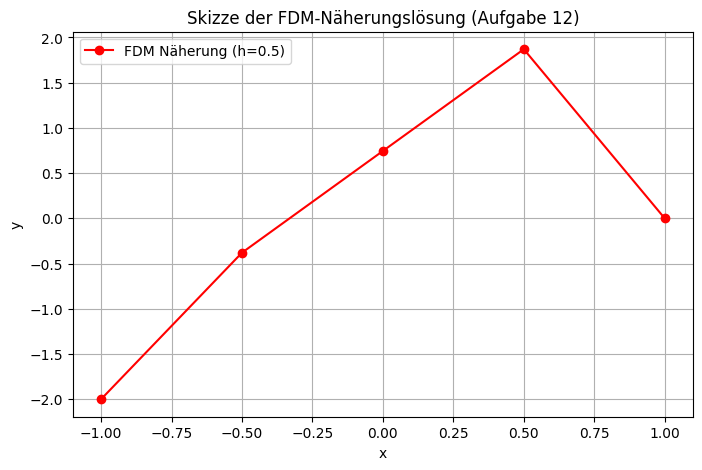

In [102]:
import numpy as np
import matplotlib.pyplot as plt

print("=== AUFGABE 12: FINITE DIFFERENZEN METHODE ===")

# Systemmatrizen aufbauen laut expliziter Herleitung
A = np.array([[-0.8, -0.1,  0.0],
              [ 0.4, -0.8,  0.4],
              [ 0.0, -0.1, -0.8]])

b = np.array([1.8 - 0.5 * np.pi, 0.0, -0.5 * np.pi])

# Gleichungssystem lösen
y_inner = np.linalg.solve(A, b)

print(f"Ergebnisse der inneren Punkte:")
print(f"  y1 (x=-0.5) = {y_inner[0]:.4f}")
print(f"  y2 (x= 0.0) = {y_inner[1]:.4f}")
print(f"  y3 (x= 0.5) = {y_inner[2]:.4f}")

# Daten für die Skizze zusammenstellen
x_nodes = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
y_nodes = np.array([-2.0, y_inner[0], y_inner[1], y_inner[2], 0.0])

# Plotten der Näherungslösung
plt.figure(figsize=(8, 5))
plt.plot(x_nodes, y_nodes, 'ro-', label='FDM Näherung (h=0.5)')
plt.title('Skizze der FDM-Näherungslösung (Aufgabe 12)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

# Aufgabe 13: Kubische Spline-Interpolation

Gegeben sind die Stützstellen und Stützwerte:
* $x_0 = 0$, $f_0 = 0$
* $x_1 = 1$, $f_1 = t$
* $x_2 = 2$, $f_2 = 0$

Die Schrittweite ist konstant: $h = x_{j+1} - x_j = 1$. Wir suchen den kubischen Spline $S(x)$, der aus zwei Intervallpolynomen besteht:
* $S_0(x)$ für $x \in [0, 1]$
* $S_1(x)$ für $x \in [1, 2]$

---

### 1. Bedingungsgleichungen für die Splinefunktion (Momentenmethode)

Zur systematischen Aufstellung nutzen wir die **Momente** $M_j = S''(x_j)$ an den Stützstellen. Für äquidistante Stützstellen mit Schrittweite $h$ lautet die allgemeine Spline-Gleichung an einer inneren Stützstelle $x_j$:

$$\frac{h}{6} M_{j-1} + \frac{2h}{3} M_j + \frac{h}{6} M_{j+1} = \frac{f_{j+1} - f_j}{h} - \frac{f_j - f_{j-1}}{h}$$

Da $h = 1$ ist, vereinfacht sich dies zu:
$$\frac{1}{6} M_{j-1} + \frac{2}{3} M_j + \frac{1}{6} M_{j+1} = (f_{j+1} - f_j) - (f_j - f_{j-1})$$

Wir haben nur eine innere Stützstelle bei $j = 1$ ($x_1 = 1$). Setzen wir $j=1$ und die Funktionswerte ein:
$$\frac{1}{6} M_0 + \frac{2}{3} M_1 + \frac{1}{6} M_2 = (0 - t) - (t - 0) = -2t$$

#### Natürliche Randbedingungen:
Ein natürlicher Spline verlangt, dass die Krümmung an den Rändern verschwindet:
$$M_0 = 0 \quad \text{und} \quad M_2 = 0$$

Damit reduziert sich das gesamte Gleichungssystem auf eine einzige Gleichung für $M_1$:
$$\frac{2}{3} M_1 = -2t \implies M_1 = -3t$$

Die berechneten Momente lauten somit in Abhängigkeit von $t$:
* $M_0 = 0$
* $M_1 = -3t$
* $M_2 = 0$

---

### 2. Berechnung der Splinefunktion in Abhängigkeit von $t$

Das Polynom $S_j(x)$ auf dem Intervall $[x_j, x_{j+1}]$ lässt sich über die berechneten Momente wie folgt darstellen:

$$S_j(x) = \frac{M_j}{6h}(x_{j+1} - x)^3 + \frac{M_{j+1}}{6h}(x - x_j)^3 + \left(\frac{f_j}{h} - \frac{h M_j}{6}\right)(x_{j+1} - x) + \left(\frac{f_{j+1}}{h} - \frac{h M_{j+1}}{6}\right)(x - x_j)$$

Wir setzen $h=1$ und die Werte für die beiden Teilintervalle ein:

#### Intervall 1: $S_0(x)$ für $x \in [0, 1]$ (mit $M_0=0, M_1=-3t, f_0=0, f_1=t$)
$$S_0(x) = 0 + \frac{-3t}{6}(x - 0)^3 + \left(0 - 0\right)(1 - x) + \left(t - \frac{-3t}{6}\right)(x - 0)$$
$$S_0(x) = -\frac{t}{2}x^3 + \left(t + \frac{t}{2}\right)x$$
$$S_0(x) = -\frac{t}{2}x^3 + \frac{3t}{2}x = \frac{t}{2}(3x - x^3)$$

#### Intervall 2: $S_1(x)$ für $x \in [1, 2]$ (mit $M_1=-3t, M_2=0, f_1=t, f_2=0$)
$$S_1(x) = \frac{-3t}{6}(2 - x)^3 + 0 + \left(t - \frac{-3t}{6}\right)(2 - x) + \left(0 - 0\right)(x - 1)$$
$$S_1(x) = -\frac{t}{2}(2 - x)^3 + \frac{3t}{2}(2 - x)$$

Umgeformt (Ausmultiplizieren oder belassen in der Taylor-Form um den Punkt 2):
$$S_1(x) = \frac{t}{2}(x - 2)^3 - \frac{3t}{2}(x - 2)$$

#### Gesamte Spline-Funktion $S(x)$:
$$
S(x) = \begin{cases} 
\frac{t}{2}(3x - x^3), & \text{für } 0 \le x \le 1 \\ 
\frac{t}{2}\left((x - 2)^3 - 3(x - 2)\right), & \text{für } 1 < x \le 2 
\end{cases}
$$

---

### 3. Änderungen bei periodischen Splines

Ein periodischer Spline setzt voraus, dass die periodische Fortsetzung der Funktion mathematisch glatt bleibt. Das bedeutet, dass der Funktionswert, die erste Ableitung und die zweite Ableitung (Krimmung) am linken und rechten Rand identisch sein müssen.

#### Die Bedingungen lauten:
1. **Gleichheit der Randmomente:** $M_0 = M_2$ (Ersetzt die Bedingung $M_0=0, M_2=0$).
2. **Gleichheit der ersten Ableitungen an den Rändern:** $S'_0(x_0) = S'_1(x_2)$.

Durch das Koppeln der Ränder erhalten wir über die Stetigkeit der ersten Ableitung eine zusätzliche Gleichung, die auch die Randmomente einbindet. Das neue Gleichungssystem für die Momente $\vec{M} = [M_0, M_1]^\top$ (da $M_2 = M_0$) wird zu einem zyklischen Gleichungssystem:

$$\frac{2}{3}M_0 + \frac{1}{6}M_1 + \frac{1}{6}M_2 = \frac{2}{3}M_0 + \frac{1}{3}M_1 = (f_1 - f_0) - (f_0 - f_2) \quad \text{(Gleichung für den Rand } x_0 \equiv x_2\text{)}$$

Das resultierende Gleichungssystem für die periodischen Momente lautet dann:
$$
\begin{pmatrix}
4 & 2 \\
1 & 4
\end{pmatrix}
\begin{pmatrix}
M_0 \\
M_1
\end{pmatrix}
= 6 \cdot
\begin{pmatrix}
2t \\
-2t
\end{pmatrix}
$$
*(Man verliert die einfache Entkopplung der Randmomente, das System bleibt voll besetzt, besch

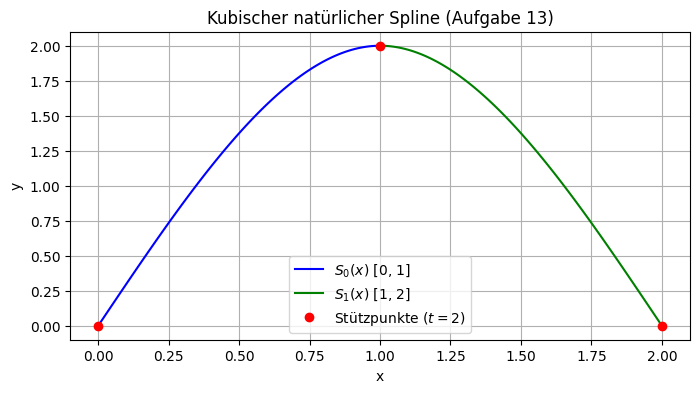

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter t definieren (Beispiel t = 2)
t = 2.0

# Definitionsbereiche für die Teilpolynome
x_zone0 = np.linspace(0, 1, 100)
x_zone1 = np.linspace(1, 2, 100)

# Spline-Gleichungen aus Aufgabe 13.2
y_zone0 = (t / 2.0) * (3 * x_zone0 - x_zone0**3)
y_zone1 = (t / 2.0) * ((x_zone1 - 2)**3 - 3 * (x_zone1 - 2))

# Plot aufbauen
plt.figure(figsize=(8, 4))
plt.plot(x_zone0, y_zone0, 'b-', label='$S_0(x)$ [0, 1]')
plt.plot(x_zone1, y_zone1, 'g-', label='$S_1(x)$ [1, 2]')
plt.plot([0, 1, 2], [0, t, 0], 'ro', label='Stützpunkte $(t=2)$')

plt.title('Kubischer natürlicher Spline (Aufgabe 13)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()